Live selling is becoming increasingly popular in Asian countries. Small vendors can now reach a wider audience and connect with many customers.

In this live selling data set ,Facebook pages of few Thai fashion and cosmetics retail sellers are present with posts of a different nature (video, photos, statuses, and links).

Engagement metrics consist of comments, shares, and reactions.

WE WILL CLEAN THE DATASET,PERFORM EDA(EXPLORATORY DATA ANAYSIS),DO PREPROCESSING OF DATSET,DESCRIBE EACH VARIABLE,PROVIDE VISUALISATION AND TRY TO FIT DIFFERENT CLUSTERING MODELS AND THEN EVALUATE EACH MODELS PERFORMANCE AND ANALYSE OUR FINDINGS.

## IMPORT LIBRARIES REQUIRED

In [80]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression


In [79]:
import warnings
warnings.filterwarnings('ignore')

## READING THE DATASET

In [81]:

df = pd.read_csv('Live.csv') 
df = df.drop(columns=['Column1','Column2','Column3','Column4'])  
df['status_published'] = pd.to_datetime(df['status_published'])

In [82]:
print("Data shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData info:")
print(df.info())


Data shape: (7050, 12)

First 5 rows:
                          status_id status_type    status_published  \
0  246675545449582_1649696485147474       video 2018-04-22 06:00:00   
1  246675545449582_1649426988507757       photo 2018-04-21 22:45:00   
2  246675545449582_1648730588577397       video 2018-04-21 06:17:00   
3  246675545449582_1648576705259452       photo 2018-04-21 02:29:00   
4  246675545449582_1645700502213739       photo 2018-04-18 03:22:00   

   num_reactions  num_comments  num_shares  num_likes  num_loves  num_wows  \
0            529           512         262        432         92         3   
1            150             0           0        150          0         0   
2            227           236          57        204         21         1   
3            111             0           0        111          0         0   
4            213             0           0        204          9         0   

   num_hahas  num_sads  num_angrys  
0          1         1       

## DESCRIPTIVE STATISTICS

Descriptive statistics summarizes and organizes the characteristics of a data set. 
It uses numerical and graphical methods to present data in a meaningful way, providing insights into the data's main features without making generalizations beyond the data itself. Essentially, it describes what the data looks like. 

In [83]:
print("\nDescriptive statistics:")
print(df.describe())


Descriptive statistics:
                    status_published  num_reactions  num_comments  \
count                           7050    7050.000000   7050.000000   
mean   2016-11-20 05:13:52.672340224     230.117163    224.356028   
min              2012-07-15 02:51:00       0.000000      0.000000   
25%              2016-03-15 16:52:45      17.000000      0.000000   
50%              2017-11-18 01:19:00      59.500000      4.000000   
75%              2018-03-09 05:26:45     219.000000     23.000000   
max              2018-06-13 01:12:00    4710.000000  20990.000000   
std                              NaN     462.625309    889.636820   

        num_shares    num_likes    num_loves     num_wows    num_hahas  \
count  7050.000000  7050.000000  7050.000000  7050.000000  7050.000000   
mean     40.022553   215.043121    12.728652     1.289362     0.696454   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000    17.000000     0.000000     0.000000

## MISSING VALUE TREATMENT:

In [4]:
#Data cleaning
print("\nMissing values before treatment:")
print(df.isnull().sum())


Missing values before treatment:
status_id           0
status_type         0
status_published    0
num_reactions       0
num_comments        0
num_shares          0
num_likes           0
num_loves           0
num_wows            0
num_hahas           0
num_sads            0
num_angrys          0
dtype: int64


In [5]:
# Simple imputation for numerical columns
num_cols = ['num_reactions', 'num_comments', 'num_shares', 'num_likes', 
            'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys']
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

In [6]:
df['status_published'] = pd.to_datetime(df['status_published'])
df['post_hour'] = df['status_published'].dt.hour
df['post_day'] = df['status_published'].dt.day_name()

In [7]:
print("\nMissing values after treatment:")
print(df.isnull().sum())


Missing values after treatment:
status_id           0
status_type         0
status_published    0
num_reactions       0
num_comments        0
num_shares          0
num_likes           0
num_loves           0
num_wows            0
num_hahas           0
num_sads            0
num_angrys          0
post_hour           0
post_day            0
dtype: int64


## EDA VISUALISATION AND OUTLIER DETECTION ALSO:

In [8]:
#total engagement metric
df['total_engagement'] = df['num_reactions'] + df['num_comments'] + df['num_shares']

([0, 1, 2, 3],
 [Text(0, 0, 'video'),
  Text(1, 0, 'photo'),
  Text(2, 0, 'link'),
  Text(3, 0, 'status')])

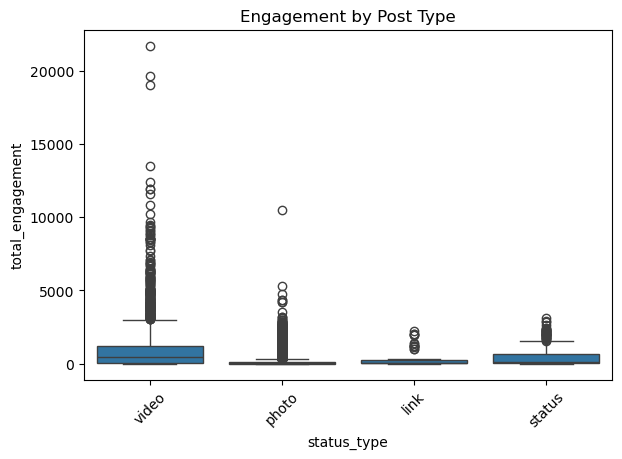

In [11]:

plt.figure(figsize=(15, 10))

# Engagement by post type
plt.subplot(2, 2, 1)
sns.boxplot(x='status_type', y='total_engagement', data=df)
plt.title('Engagement by Post Type')
plt.xticks(rotation=45)


Text(0, 0.5, 'Total Count')

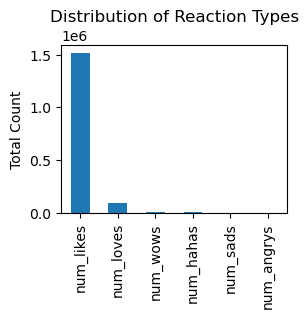

In [12]:
# Reaction types distribution
plt.subplot(2, 2, 2)
reaction_cols = ['num_likes', 'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys']
df[reaction_cols].sum().plot(kind='bar')
plt.title('Distribution of Reaction Types')
plt.ylabel('Total Count')

Text(0.5, 1.0, 'Engagement by Hour of Day')

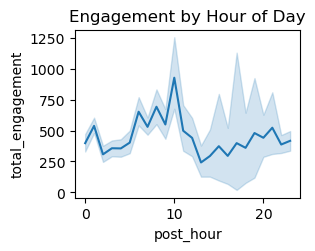

In [13]:
# Engagement by hour
plt.subplot(2, 2, 3)
sns.lineplot(x='post_hour', y='total_engagement', data=df)
plt.title('Engagement by Hour of Day')


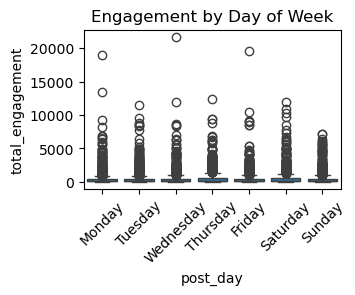

In [14]:
# Engagement by day
plt.subplot(2, 2, 4)
sns.boxplot(x='post_day', y='total_engagement', data=df, 
           order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Engagement by Day of Week')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Data Preprocessing for Clustering

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   status_id         7050 non-null   object        
 1   status_type       7050 non-null   object        
 2   status_published  7050 non-null   datetime64[ns]
 3   num_reactions     7050 non-null   float64       
 4   num_comments      7050 non-null   float64       
 5   num_shares        7050 non-null   float64       
 6   num_likes         7050 non-null   float64       
 7   num_loves         7050 non-null   float64       
 8   num_wows          7050 non-null   float64       
 9   num_hahas         7050 non-null   float64       
 10  num_sads          7050 non-null   float64       
 11  num_angrys        7050 non-null   float64       
 12  post_hour         7050 non-null   int32         
 13  post_day          7050 non-null   object        
 14  total_engagement  7050 n

In [18]:
##explore status_id variable
#view the labels in the variable

df['status_id'].unique()

array(['246675545449582_1649696485147474',
       '246675545449582_1649426988507757',
       '246675545449582_1648730588577397', ...,
       '1050855161656896_1060126464063099',
       '1050855161656896_1058663487542730',
       '1050855161656896_1050858841656528'], dtype=object)

In [19]:
 #view how many different types of variables are there

len(df['status_id'].unique())

6997

In [20]:
##Explore status_published variable
# view the labels in the variable

df['status_published'].unique()

<DatetimeArray>
['2018-04-22 06:00:00', '2018-04-21 22:45:00', '2018-04-21 06:17:00',
 '2018-04-21 02:29:00', '2018-04-18 03:22:00', '2018-04-18 02:14:00',
 '2018-04-18 00:24:00', '2018-04-17 07:42:00', '2018-04-17 03:33:00',
 '2018-04-11 04:53:00',
 ...
 '2016-09-25 13:29:00', '2016-09-24 08:15:00', '2016-09-24 06:07:00',
 '2016-09-24 05:07:00', '2016-09-24 04:37:00', '2016-09-24 02:58:00',
 '2016-09-23 11:19:00', '2016-09-21 23:03:00', '2016-09-20 00:43:00',
 '2016-09-10 10:30:00']
Length: 6913, dtype: datetime64[ns]

In [21]:
# view how many different types of variables are there

len(df['status_published'].unique())

6913

In [23]:
# view the labels in the variable

df['status_type'].unique()

array(['video', 'photo', 'link', 'status'], dtype=object)

In [24]:
# view how many different types of variables are there

len(df['status_type'].unique())

4

In [84]:
#Drop status_id and status_published variable from the dataset¶
x=df.drop(['status_id', 'status_published'], axis=1)
x.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   status_type    7050 non-null   object
 1   num_reactions  7050 non-null   int64 
 2   num_comments   7050 non-null   int64 
 3   num_shares     7050 non-null   int64 
 4   num_likes      7050 non-null   int64 
 5   num_loves      7050 non-null   int64 
 6   num_wows       7050 non-null   int64 
 7   num_hahas      7050 non-null   int64 
 8   num_sads       7050 non-null   int64 
 9   num_angrys     7050 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 550.9+ KB


In [54]:
##declare feature vector and target variable

x=x
y=df['status_type']

In [56]:
# Select features for clustering
cluster_features = ['num_reactions', 'num_comments', 'num_shares', 
                   'num_likes', 'num_loves', 'num_wows', 'num_hahas', 
                   'total_engagement', 'post_hour']

X = df[cluster_features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
x['status_type'] = le.fit_transform(x['status_type'])
y = le.transform(y)

In [57]:
x.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,post_hour,post_day,total_engagement
0,3,529.0,512.0,262.0,432.0,92.0,3.0,1.0,1.0,0.0,6,Sunday,1303.0
1,1,150.0,0.0,0.0,150.0,0.0,0.0,0.0,0.0,0.0,22,Saturday,150.0
2,3,227.0,236.0,57.0,204.0,21.0,1.0,1.0,0.0,0.0,6,Saturday,520.0
3,1,111.0,0.0,0.0,111.0,0.0,0.0,0.0,0.0,0.0,2,Saturday,111.0
4,1,213.0,0.0,0.0,204.0,9.0,0.0,0.0,0.0,0.0,3,Wednesday,213.0


In [38]:
X_scaled = pd.DataFrame(X, columns=['num_reactions', 'num_comments', 'num_shares', 
                   'num_likes', 'num_loves', 'num_wows', 'num_hahas',
                   'total_engagement', 'post_hour'])

In [39]:
X_scaled.head()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,total_engagement,post_hour
0,529.0,512.0,262.0,432.0,92.0,3.0,1.0,1303.0,6
1,150.0,0.0,0.0,150.0,0.0,0.0,0.0,150.0,22
2,227.0,236.0,57.0,204.0,21.0,1.0,1.0,520.0,6
3,111.0,0.0,0.0,111.0,0.0,0.0,0.0,111.0,2
4,213.0,0.0,0.0,204.0,9.0,0.0,0.0,213.0,3


In [40]:
X_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   num_reactions     7050 non-null   float64
 1   num_comments      7050 non-null   float64
 2   num_shares        7050 non-null   float64
 3   num_likes         7050 non-null   float64
 4   num_loves         7050 non-null   float64
 5   num_wows          7050 non-null   float64
 6   num_hahas         7050 non-null   float64
 7   total_engagement  7050 non-null   float64
 8   post_hour         7050 non-null   int32  
dtypes: float64(8), int32(1)
memory usage: 468.3 KB


## CLUSTERING PART:

The task of grouping data points based on their similarity with each other is called Clustering or Cluster Analysis. 

This method is defined under the branch of unsupervised learning, which aims at gaining insights from unlabelled data points.

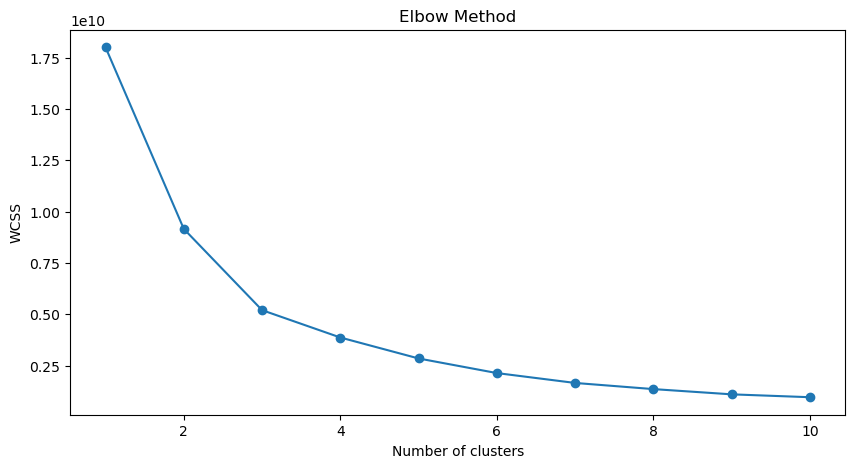

In [41]:
# Determine optimal no. of clusters for K-Means
# Elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

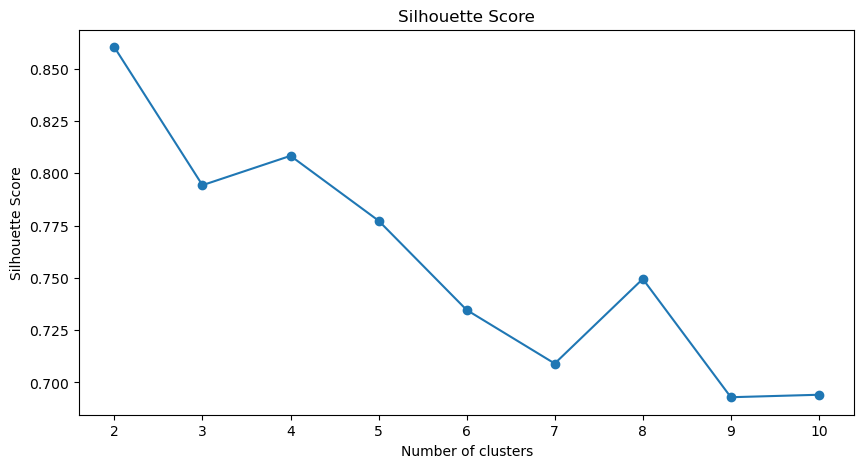

In [43]:
# Silhouette score
silhouette_scores = []
for n_cluster in range(2, 11):
    kmeans = KMeans(n_clusters=n_cluster, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [58]:
#2 clusters
kmeans = KMeans(n_clusters=2,random_state=42)

kmeans.fit(X_scaled)

labels = kmeans.labels_

# check how many of the samples were correctly labeled

correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))


Result: 73 out of 7050 samples were correctly labeled.
Accuracy score: 0.01


In [59]:
#3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X_scaled)

# check how many of the samples were correctly labeled
labels = kmeans.labels_

correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 122 out of 7050 samples were correctly labeled.
Accuracy score: 0.02


In [64]:
# Based on the plots, choose optimal k
optimal_k = 4  

                                                  DIFFERENT CLUSTERING MODELS:

1.K-Means Clustering is an Unsupervised Machine Learning algorithm which groups unlabeled dataset into different clusters. It is used to organize data into groups based on their similarity.

2.Hierarchical clustering is used to group similar data points together based on their similarity creating a hierarchy or tree-like structure. The key idea is to begin with each data point as its own separate cluster and then progressively merge or split them based on their similarity. 

3.DBSCAN is a density-based clustering algorithm that groups data points that are closely packed together and marks outliers as noise based on their density in the feature space. It identifies clusters as dense regions in the data space separated by areas of lower density. Unlike K-Means or hierarchical clustering which assumes clusters are compact and spherical, DBSCAN perform well in handling real-world data irregularities

4.Gaussian Mixture Model is a probabilistic model that assumes all data points are generated from a mixture of several Gaussian distributions with unknown parameters. Unlike hard clustering methods like K-Means that assigns each data point to one cluster based on the closest centroid which often doesn't align with the complexity of real-world data. GMMs perform soft clustering meaning each data point belongs to multiple clusters with certain probabilities.

In [66]:
# Clustering models
# K-Means
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['kmeans_cluster'] = kmeans_labels

#Hierarchical Clustering
agg = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)
df['hierarchical_cluster'] = agg_labels

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)  
dbscan_labels = dbscan.fit_predict(X_scaled)
df['dbscan_cluster'] = dbscan_labels

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
df['gmm_cluster'] = gmm_labels

## MODEL EVALUATION

In [67]:

def evaluate_clustering(X, labels):
    if len(set(labels)) > 1: 
        print(f"Silhouette Score: {silhouette_score(X, labels):.3f}")
        print(f"Davies-Bouldin Index: {davies_bouldin_score(X, labels):.3f}")
        print(f"Calinski-Harabasz Score: {calinski_harabasz_score(X, labels):.3f}")
    else:
        print("Only one cluster found - cannot compute metrics")

print("\nK-Means Evaluation:")
evaluate_clustering(X_scaled, kmeans_labels)

print("\nHierarchical Clustering Evaluation:")
evaluate_clustering(X_scaled, agg_labels)

print("\nDBSCAN Evaluation:")
evaluate_clustering(X_scaled, dbscan_labels)

print("\nGMM Evaluation:")
evaluate_clustering(X_scaled, gmm_labels)



K-Means Evaluation:
Silhouette Score: 0.677
Davies-Bouldin Index: 1.003
Calinski-Harabasz Score: 2703.918

Hierarchical Clustering Evaluation:
Silhouette Score: 0.633
Davies-Bouldin Index: 1.036
Calinski-Harabasz Score: 2536.921

DBSCAN Evaluation:
Silhouette Score: -0.032
Davies-Bouldin Index: 1.842
Calinski-Harabasz Score: 207.467

GMM Evaluation:
Silhouette Score: 0.199
Davies-Bouldin Index: 1.885
Calinski-Harabasz Score: 936.283


Key Metrics:

1.Silhouette Score (Higher is better; range: -1 to 1)

2.Davies-Bouldin Index (Lower is better)

3.Calinski-Harabasz Score (Higher is better)

BY COMPARISON,
   K-Means has the highest Silhouette Score, lowest Davies-Bouldin Index, and highest Calinski-Harabasz Score, all of which suggest that it forms the most compact and well-separated clusters.

## CLUSTER ANALYSIS OR VISUALISATION

In [68]:
# Cluster analysis
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(15, 10))


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0.5, 1.0, 'K-Means Clusters')

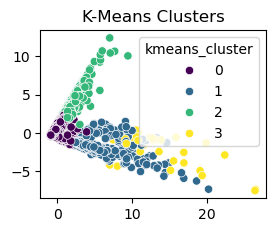

In [69]:
# K-Means clusters
plt.subplot(2, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['kmeans_cluster'], palette='viridis')
plt.title('K-Means Clusters')

Text(0.5, 1.0, 'Hierarchical Clusters')

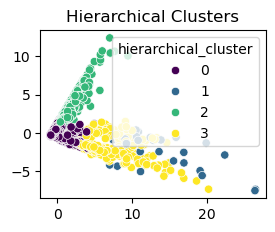

In [70]:
# Hierarchical clusters
plt.subplot(2, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['hierarchical_cluster'], palette='viridis')
plt.title('Hierarchical Clusters')

Text(0.5, 1.0, 'DBSCAN Clusters')

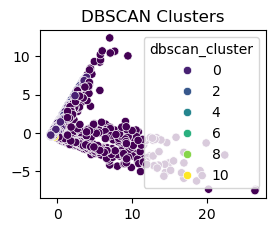

In [71]:
# DBSCAN clusters
plt.subplot(2, 2, 3)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['dbscan_cluster'], palette='viridis')
plt.title('DBSCAN Clusters')

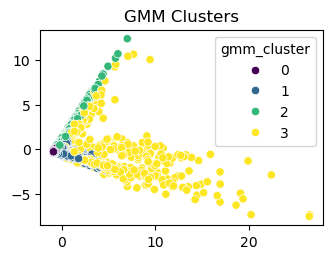

In [72]:
# GMM clusters
plt.subplot(2, 2, 4)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['gmm_cluster'], palette='viridis')
plt.title('GMM Clusters')

plt.tight_layout()
plt.show()

In [73]:
#Interpret clusters
# Analyze cluster characteristics
cluster_profile = df.groupby('kmeans_cluster')[cluster_features].mean()
print("\nCluster Profiles (K-Means):")
print(cluster_profile)


Cluster Profiles (K-Means):
                num_reactions  num_comments  num_shares    num_likes  \
kmeans_cluster                                                         
0                  112.134366     77.972494   17.680683   104.527980   
1                  577.662500   3145.634375  438.371875   449.075000   
2                 1827.954054     63.308108   12.224324  1821.872973   
3                 1522.617647   1718.500000  750.264706  1088.617647   

                 num_loves    num_wows  num_hahas  total_engagement  post_hour  
kmeans_cluster                                                                  
0                 6.509327    0.539836   0.318527        207.787543   7.818685  
1               116.159375    4.056250   5.728125       4161.668750   7.168750  
2                 3.375676    2.462162   0.200000       1903.486486   8.667568  
3               298.205882  101.941176  29.058824       3991.382353   6.941176  


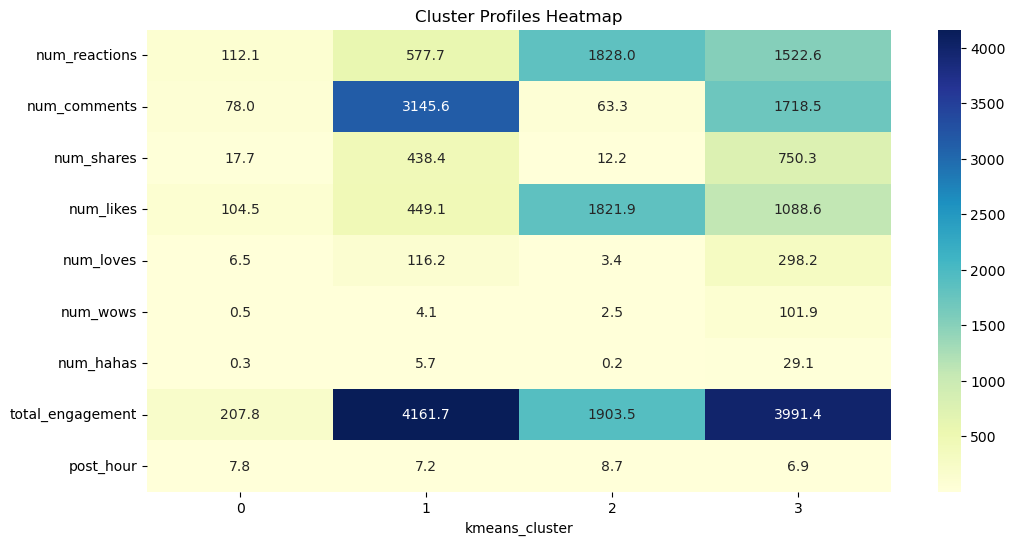

In [74]:
# Visualize cluster profiles
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile.T, cmap='YlGnBu', annot=True, fmt='.1f')
plt.title('Cluster Profiles Heatmap')
plt.show()


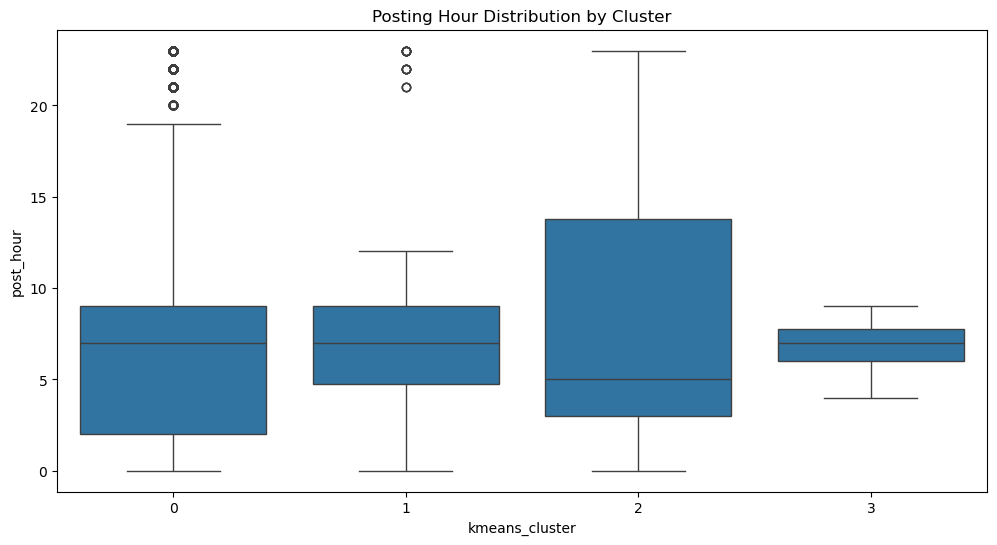

In [75]:
# Time analysis by cluster
plt.figure(figsize=(12, 6))
sns.boxplot(x='kmeans_cluster', y='post_hour', data=df)
plt.title('Posting Hour Distribution by Cluster')
plt.show()

<Figure size 1200x600 with 0 Axes>

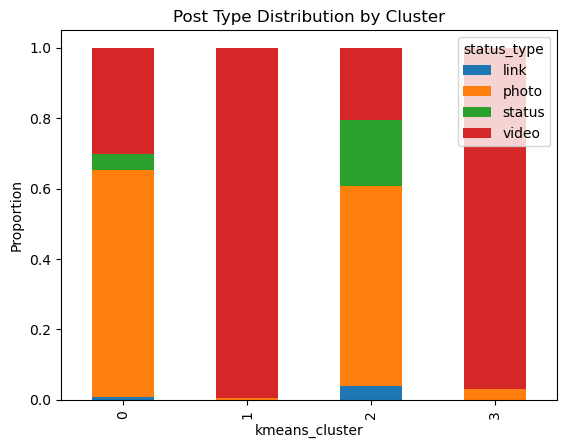

In [76]:
# Post type analysis by cluster
plt.figure(figsize=(12, 6))
pd.crosstab(df['kmeans_cluster'], df['status_type'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Post Type Distribution by Cluster')
plt.ylabel('Proportion')
plt.show()

   STEPS :

To accomplish this:
- imported necessary libraries and modules
- Prepare and clean the dataset by handling missing values and detecting outliers and dropping columns not required.
- We provided descriptive statistics on each variablle to provide details of the data.
- Explore and visualize key features to understand data distribution and relationships.  
- Apply dimensionality reduction techniques like PCA to identify important features and reduce redundancy.  
- Use multiple clustering algorithms (such as K-Means, DBSCAN ,Hierarchical Clustering,Gaussian mixture model) to find natural groupings in the data.  
- Evaluate and compare the clustering results using performance metrics like Silhouette score,Davies–Bouldin index,and Calinski-Harabasz Score.  
- Draw insights and practical recommendations based on the clustering outcomes.

                                                      CONCLUSION:-
       
            Key Metrics:

1.Silhouette Score (Higher is better; range: -1 to 1)

2.Davies-Bouldin Index (Lower is better)

3.Calinski-Harabasz Score (Higher is better)

K-Means has the highest Silhouette Score, lowest Davies-Bouldin Index, and highest Calinski-Harabasz Score, all of which suggest that it forms the most compact and well-separated clusters.

Hierarchical Clustering performs similarly but slightly worse than K-Means.

DBSCAN and GMM perform significantly worse based on all three metrics.